# Signal detection: the mixed-model reference example

One binary unknown in an otherwise continuous model: was a pulse of known shape present in a noisy recording?

This notebook is the worked reference behind the discrete-parameter machinery in the docs:

* `GUIDE.md` §5 samples exactly this model with `Gibbs`, `RandomWalkMetropolis`, and `DiscreteMetropolis`.
* `INTERFACE.md` §12.8 uses it as the mixed-model test oracle: the model is linear-Gaussian given $z$, so the detection probability and conditional moments have exact answers, computed in §4 below.
* `DECISIONS.md` §5 records how working through this model led to promoting `Categorical`, `DiscreteMetropolis`, and the `Gibbs` compositor into v1.

Everything here is plain NumPy, deliberately: the point is the *mechanism*.
A discrete sampler is just another sampler behind the same ask → evaluate → tell contract, composed with the continuous kernel by deterministic alternation (Metropolis-within-Gibbs).
For a model this simple you could, and per `GUIDE.md` §5 should, integrate $z$ out; at the end we do exactly that, as the ground-truth check on the sampler.

## 1. The toy model: is there a signal in the noise?

A detector records a noisy channel at $n = 60$ time points. A pulse of **known shape,
size and arrival time** may or may not have arrived halfway through the recording —
think of a radar return, a calibration pulse, or (upside-down) an exoplanet transit dip.
What we don't know is the detector's baseline level, how noisy it is, and whether the
pulse is actually in this recording:

$$
y_t = \mu + z\, s_t + \varepsilon_t,
\qquad \varepsilon_t \sim \mathcal N(0, \sigma^2), \quad t = 1,\dots,n,
$$

where $s_t$ is the known pulse template (a bump of height $0.5$ centred at $t = 30$).
The three unknowns:

* $\mu$ — the baseline level of the detector *(continuous)*,
* $\sigma$ — the noise level *(continuous, positive)*,
* $z \in \{0, 1\}$ — **is the pulse there?** *(binary)*.

Priors: $\mu \sim \mathcal N(0, 5^2)$, $\sigma \sim \text{Half-Normal}(2)$,
$z \sim \text{Bernoulli}(\tfrac12)$.

Note what makes this comfortable to explain: $\mu$ is the baseline and $\sigma$ is the
noise level *no matter what $z$ is*. The discrete parameter only asks whether a known
bump sits on top. $P(z = 1 \mid y)$ is the probability the pulse is present — as direct
as a posterior quantity gets.

The data are generated **with the pulse present but weak** (its height is half the noise
level), so the answer is genuinely uncertain and the chain must take both hypotheses
seriously.


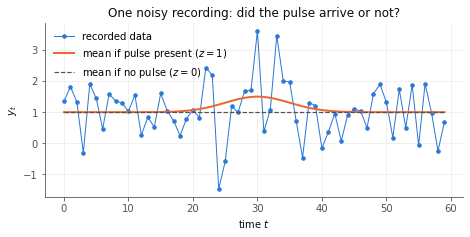

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -- palette / style -----------------------------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2 = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.6,
    "figure.figsize": (7.5, 3.2), "font.size": 10,
})

# -- the known pulse template ---------------------------------------------------
n  = 60
t  = np.arange(n)
A, t0, w = 0.5, 30.0, 5.0                     # height, centre, width -- all KNOWN
s  = A * np.exp(-(t - t0) ** 2 / (2 * w ** 2))

# -- ground truth and data ------------------------------------------------------
rng_data = np.random.default_rng(1)

mu_true, sigma_true, z_true = 1.0, 1.0, 1     # pulse IS present, but weak
y = mu_true + z_true * s + rng_data.normal(0.0, sigma_true, n)

# prior scales
s_mu, tau_sigma = 5.0, 2.0

fig, ax = plt.subplots()
ax.plot(t, y, color=BLUE, lw=1.0, marker="o", ms=3.5, label="recorded data")
ax.plot(t, mu_true + s, color=ORANGE, lw=2, label="mean if pulse present ($z=1$)")
ax.plot(t, np.full(n, mu_true), color=INK2, lw=1.2, ls="--",
        label="mean if no pulse ($z=0$)")
ax.set(xlabel="time $t$", ylabel="$y_t$",
       title="One noisy recording: did the pulse arrive or not?")
ax.legend(frameon=False, loc="upper left")
plt.show()

## 2. The user's side: one log-density over the full, mixed parameter set

In bayesrs the user supplies a single scalar function of the parameters (`GUIDE.md` §2).
Nothing about that changes when one of the parameters is discrete: the function below takes the *full* parameter set $(\mu, \sigma, z)$ and returns one number.

One detail worth attention: $\sigma$ must be positive, and a raw random-walk proposal will occasionally propose $\sigma' \le 0$.
The cleanest contract is that the log-density simply returns $-\infty$ for points outside the support: Metropolis then rejects them with certainty, no special cases needed.
(In bayesrs the transform layer of `INTERFACE.md` §4.2 instead puts $\sigma$ on a log scale so proposals can never leave the support, and discrete parameters pass through that layer untouched.
Here we keep the raw scale to stay minimal.)

How the parameters are split into blocks, and which kernel owns which block, is entirely the sampler's business.
The model code neither knows nor cares.

In [2]:
LOG_HALF = np.log(0.5)
LOG_2PI  = np.log(2.0 * np.pi)

def log_normal_pdf(v, mean, sd):
    return -0.5 * ((v - mean) / sd) ** 2 - np.log(sd) - 0.5 * LOG_2PI

def log_pdf(mu, sigma, z):
    # log posterior density (up to a constant) of the full parameter set
    if sigma <= 0.0:
        return -np.inf                        # outside the support
    # priors
    lp  = log_normal_pdf(mu, 0.0, s_mu)
    lp += np.log(2.0) + log_normal_pdf(sigma, 0.0, tau_sigma)   # half-normal
    lp += LOG_HALF                            # z ~ Bernoulli(1/2)
    # likelihood
    mean = mu + z * s
    lp += log_normal_pdf(y, mean, sigma).sum()
    return lp

## 3. Two kernels, one contract

We run a **Metropolis-within-Gibbs** scheme: each iteration first updates the continuous block $(\mu, \sigma)$ with $z$ held fixed, then updates $z$ with $(\mu, \sigma)$ held fixed.
Each block is a complete ask → evaluate → tell exchange:

* **Continuous block**: random-walk Metropolis.
  Propose $(\mu', \sigma') = (\mu, \sigma) + \mathcal N(0, s^2 I)$, evaluate the log-density at the proposal, accept with probability $\min\{1, \exp(\ell' - \ell)\}$.
* **Discrete block**: Metropolis with a 50:50 proposal.
  Propose $z' \sim \text{Uniform}\{0, 1\}$ *independently of the current value*, evaluate, and accept by the same rule.

Both proposals are **symmetric** ($q(u' \mid u) = q(u \mid u')$), so in both cases the acceptance probability involves only the ratio of posterior densities: the Metropolis rule is literally the same line of code.

One quirk of the 50:50 proposal worth flagging: half of its proposals are the current state, which are accepted trivially and waste an evaluation.
This is exactly why the shipped `DiscreteMetropolis` proposes **uniformly over the other $k-1$ states** instead (`INTERFACE.md` §5.2): for two states that is the deterministic flip, which probes the other state every time.
Both are symmetric kernels behind the same two verbs; we keep the simpler, wasteful one here because it is the easiest to write down.

In the loop below, the comments mark which lines belong to the sampler (`ask`, `tell`) and which single line in each block is the user's (`evaluate`).

In [3]:
rng_mc = np.random.default_rng(2026)

n_iter = 60_000
burn   = 5_000
step   = 0.15              # std dev of the normal proposal on (mu, sigma)

# initial state (deliberately away from the truth)
mu, sigma, z = 0.0, 2.0, 0
lp = log_pdf(mu, sigma, z)

chain = np.empty((n_iter, 3))
n_acc_cont = 0
n_acc_disc = 0

for i in range(n_iter):

    # ---- continuous block: (mu, sigma) | z  -- random-walk Metropolis ----
    m_prop = mu    + step * rng_mc.normal()          # ask    
    s_prop = sigma + step * rng_mc.normal()          #
    lp_prop = log_pdf(m_prop, s_prop, z)             # evaluate  (user code)
    if np.log(rng_mc.uniform()) < lp_prop - lp:      # tell
        mu, sigma, lp = m_prop, s_prop, lp_prop      #
        n_acc_cont += 1                              #

    # ---- discrete block: z | (mu, sigma)  -- Metropolis, 50:50 proposal ----
    z_prop = int(rng_mc.uniform() < 0.5)             # ask    
    lp_prop = log_pdf(mu, sigma, z_prop)             # evaluate  (user code)
    if np.log(rng_mc.uniform()) < lp_prop - lp:      # tell (same rule --
        z, lp = z_prop, lp_prop                      #  the proposal is
        n_acc_disc += 1                              #  symmetric)

    chain[i] = mu, sigma, z

mu_s, sigma_s, z_s = chain[burn:].T

print(f"acceptance rate, continuous block : {n_acc_cont / n_iter:.3f}")
print(f"acceptance rate, discrete block   : {n_acc_disc / n_iter:.3f}")
print(f"posterior mean  mu                : {mu_s.mean():.3f}   (true {mu_true})")
print(f"posterior mean  sigma             : {sigma_s.mean():.3f}   (true {sigma_true})")
print(f"P(z = 1 | y)  (MCMC estimate)     : {z_s.mean():.3f}")

acceptance rate, continuous block : 0.380
acceptance rate, discrete block   : 0.672
posterior mean  mu                : 0.968   (true 1.0)
posterior mean  sigma             : 0.894   (true 1.0)
P(z = 1 | y)  (MCMC estimate)     : 0.824


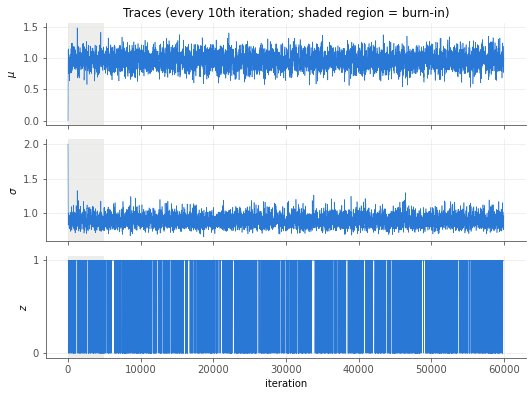

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(7.5, 5.6), sharex=True)
thin = slice(None, None, 10)                     # plot every 10th point
it = np.arange(n_iter)[thin]

for ax, series, label in zip(axes[:2], (chain[:, 0], chain[:, 1]),
                             (r"$\mu$", r"$\sigma$")):
    ax.plot(it, series[thin], color=BLUE, lw=0.6)
    ax.set_ylabel(label)

axes[2].plot(it, chain[:, 2][thin], color=BLUE, lw=0.6, drawstyle="steps-post")
axes[2].set(ylabel="$z$", xlabel="iteration", yticks=[0, 1])

for ax in axes:
    ax.axvspan(0, burn, color=INK2, alpha=0.10, lw=0)
axes[0].set_title("Traces (every 10th iteration; shaded region = burn-in)")
plt.tight_layout()
plt.show()

### How the two hypotheses explain the bump

The two blocks are coupled in an intuitive way. When the chain says $z = 0$, the bump in
the data still has to be explained by *something* — so those draws shift $\mu$ up, the
baseline absorbing part of the bump, and lean on $\sigma$ slightly (with a pulse this
weak the noise level barely needs to budge; a stronger pulse would push $\sigma$ up
visibly). When $z = 1$, the template accounts for the bump and the baseline settles
lower. Splitting the posterior draws by the value of $z$ makes this visible — clearly
for $\mu$, faintly for $\sigma$.

This is exactly why the alternation works: each block's conditional posterior depends on
the other block's current state, and the ask/evaluate/tell exchanges pass that state
back and forth through nothing more than the log-density. It is also a nice talking
point for non-specialist audiences: the sampler is literally weighing "*pulse*" against "*just a
noisy patch*" and bookkeeping the consequences for the noise estimate.


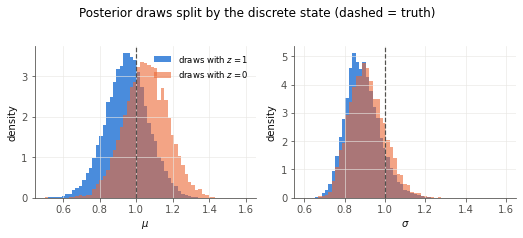

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2))
for ax, series, label, lim in zip(
        axes, (mu_s, sigma_s), (r"$\mu$", r"$\sigma$"), ((0.5, 1.6), (0.6, 1.6))):
    bins = np.linspace(*lim, 60)
    ax.hist(series[z_s == 1], bins=bins, density=True, color=BLUE,  alpha=0.85,
            label=r"draws with $z=1$")
    ax.hist(series[z_s == 0], bins=bins, density=True, color=ORANGE, alpha=0.6,
            label=r"draws with $z=0$")
    ax.set(xlabel=label, ylabel="density")
axes[0].axvline(mu_true, color=INK2, ls="--", lw=1.2)
axes[1].axvline(sigma_true, color=INK2, ls="--", lw=1.2)
axes[0].legend(frameon=False, fontsize=8.5)
fig.suptitle("Posterior draws split by the discrete state (dashed = truth)", y=1.02)
plt.tight_layout()
plt.show()

## 4. Checking against the exact answer

The model is linear-Gaussian in $\mu$ *given* $(\sigma, z)$, so $\mu$ integrates out
analytically; the remaining one-dimensional integral over $\sigma$ we do by quadrature
on a fine grid. That gives the marginal likelihood of each hypothesis,

$$
p(y \mid z) = \int p(y \mid \sigma, z)\, p(\sigma)\, d\sigma,
\qquad
P(z=1 \mid y) = \frac{p(y \mid 1)}{p(y \mid 0) + p(y \mid 1)}
$$

(the $\tfrac12$ priors cancel), plus exact conditional moments
$\mathbb E[\mu \mid y, z{=}1]$ and $\mathbb E[\sigma \mid y, z{=}1]$ from the same grid.
This is the marginalisation we said we would *not* use for inference: here it serves as an independent test oracle, which is exactly the role it plays in the verification plan (`INTERFACE.md` §12.8).


In [6]:
from scipy.stats import multivariate_normal
from scipy.special import logsumexp

sig_grid = np.arange(0.02, 6.0, 0.01)
log_prior_sig = np.log(2.0) + log_normal_pdf(sig_grid, 0.0, tau_sigma)

def log_p_y_given_sigma(z):
    # mu integrated out analytically:  y - z s ~ N(mu 1, sigma^2 I), mu ~ N(0, s_mu^2)
    r = y - z * s
    ones = np.ones((n, n))
    out = np.empty(sig_grid.size)
    for i, sg in enumerate(sig_grid):
        out[i] = multivariate_normal.logpdf(r, np.zeros(n),
                                            s_mu**2 * ones + sg**2 * np.eye(n))
    return out

d = sig_grid[1] - sig_grid[0]
lml = {z: log_p_y_given_sigma(z) for z in (0, 1)}
log_p_y = {z: logsumexp(lml[z] + log_prior_sig) + np.log(d) for z in (0, 1)}
pz1_exact = 1.0 / (1.0 + np.exp(log_p_y[0] - log_p_y[1]))

# exact conditional moments given z = 1, from the same grid
w1 = np.exp(lml[1] + log_prior_sig - logsumexp(lml[1] + log_prior_sig))
r1 = (y - s).sum()
mu_post_given_sig = (r1 / sig_grid**2) / (n / sig_grid**2 + 1.0 / s_mu**2)
mu_exact    = (w1 * mu_post_given_sig).sum()
sigma_exact = (w1 * sig_grid).sum()

# Monte Carlo standard error of the P(z=1) estimate, by batch means
n_batches = 50
batches = z_s[: len(z_s) // n_batches * n_batches].reshape(n_batches, -1).mean(axis=1)
mcse = batches.std(ddof=1) / np.sqrt(n_batches)

pz1_mcmc = z_s.mean()
m1 = z_s == 1

print(f"P(z=1 | y)   exact : {pz1_exact:.4f}")
print(f"P(z=1 | y)   MCMC  : {pz1_mcmc:.4f}   (batch-means MCSE {mcse:.4f})")
print()
print(f"E[mu    | y, z=1]   exact : {mu_exact:.4f}    MCMC : {mu_s[m1].mean():.4f}")
print(f"E[sigma | y, z=1]   exact : {sigma_exact:.4f}    MCMC : {sigma_s[m1].mean():.4f}")

assert abs(pz1_mcmc - pz1_exact) < 4 * mcse + 0.005, "MCMC estimate inconsistent with exact answer"
print("\nMCMC estimate agrees with the exact posterior detection probability.")

P(z=1 | y)   exact : 0.8252
P(z=1 | y)   MCMC  : 0.8236   (batch-means MCSE 0.0035)

E[mu    | y, z=1]   exact : 0.9506    MCMC : 0.9497
E[sigma | y, z=1]   exact : 0.8880    MCMC : 0.8899

MCMC estimate agrees with the exact posterior detection probability.


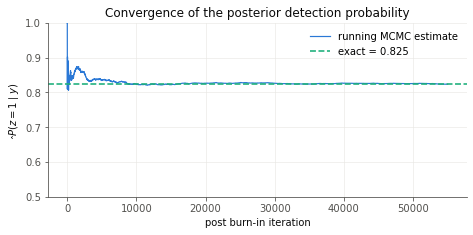

In [7]:
running = np.cumsum(z_s) / np.arange(1, len(z_s) + 1)
fig, ax = plt.subplots()
ax.plot(np.arange(len(running))[::10], running[::10], color=BLUE, lw=1.2,
        label="running MCMC estimate")
ax.axhline(pz1_exact, color=AQUA, lw=1.6, ls="--", label=f"exact = {pz1_exact:.3f}")
ax.set(xlabel="post burn-in iteration", ylabel=r"$\hat P(z=1 \mid y)$",
       title="Convergence of the posterior detection probability", ylim=(0.5, 1.0))
ax.legend(frameon=False)
plt.show()

## 5. The same model through bayesrs

Everything above was two kernels driven through the same two verbs, with the alternation and the density bookkeeping written by hand.
In bayesrs the compositor owns that bookkeeping (`GUIDE.md` §5): declare the space, block the parameters, keep the canonical loop.

```python
space = ParamSpace(
    mu    = Real(),
    sigma = Bounded(0, None),
    z     = Categorical(2, labels=["absent", "present"]),
)

s = Gibbs(space, x0, seed=42, blocks=[
    Block(["mu", "sigma"], RandomWalkMetropolis),
    Block(["z"],           DiscreteMetropolis),
])

while s.n_draws < N:
    s.tell(log_post(s.ask()))
```

Points of contact with this notebook, and where the library improves on it:

1. One draw is one full sweep over the blocks, so the loop above goes round twice per draw.
   "Count draws, not iterations" (`INTERFACE.md` §2) is what makes that invisible to the user.
2. The transform layer samples $\sigma$ in log space, so the $-\infty$ guard in our `log_pdf` becomes unnecessary: every value the sampler hands over is strictly positive by construction (`INTERFACE.md` §4.2).
3. `DiscreteMetropolis` uses the deterministic flip rather than the 50:50 proposal, so no evaluation is ever spent re-proposing the current state (`INTERFACE.md` §5.2).
4. The density told for an accepted point is carried across the block boundary, so a sweep costs exactly the sum of its blocks' evaluations, with no re-evaluation at the seams (`INTERFACE.md` §5.3).
5. Hand-rolled alternation like the loop in §3 remains fully supported as external composition, with one obligation the compositor otherwise hides: `reanchor` the other sampler after a block accepts (`INTERFACE.md` §5.4).
   Our NumPy loop quietly gets this right by threading the single `lp` variable through both blocks; that shared variable is precisely the bookkeeping `reanchor` makes explicit across two encapsulated samplers.

## 6. Where this goes next

The same structure scales from this toy to the cases users actually bring: categorical $z$ with $K > 2$ states (mixture allocations, change-point locations, model indices), several discrete parameters (one block each, or one block jointly), and unknown signal *amplitude*, the natural next step for this very model.
That last one is worth a warning label: once the amplitude is a free parameter that only matters when $z = 1$, its draws during $z = 0$ stretches wander under the prior (the "ghost parameter" effect), priors on switched-off parameters must be proper, and pseudo-prior tricks (Carlin & Chib) exist to keep mixing healthy.
Those are modelling concerns, not interface concerns.

None of them require anything beyond what this notebook exercised: kernels that own parameter blocks, a compositor (or your own driver loop) that assembles the full parameter set, and the unchanged contract: **ask → evaluate → tell**.